In [1]:
import kagglehub

# Download latest version
path = kagglehub.dataset_download("jp797498e/twitter-entity-sentiment-analysis")

print("Path to dataset files:", path)

100%|██████████████████████████████████████████████████████████████████████████████| 1.99M/1.99M [00:02<00:00, 698kB/s]

Extracting files...
Path to dataset files: C:\Users\Abhishek\.cache\kagglehub\datasets\jp797498e\twitter-entity-sentiment-analysis\versions\2


In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [2]:
data = pd.read_csv('twitter_training.csv',names=['id', 'topic', 'sentiment', 'tweet'])

In [3]:
val = pd.read_csv('twitter_validation.csv',names=['id', 'topic', 'sentiment', 'tweet'])

In [4]:
data.head()

,id,topic,sentiment,tweet
0,2401,Borderlands,Positive,im getting on borderlands and i will murder yo...
1,2401,Borderlands,Positive,I am coming to the borders and I will kill you...
2,2401,Borderlands,Positive,im getting on borderlands and i will kill you ...
3,2401,Borderlands,Positive,im coming on borderlands and i will murder you...
4,2401,Borderlands,Positive,im getting on borderlands 2 and i will murder ...


In [5]:
val.head()

,id,topic,sentiment,tweet
0,3364,Facebook,Irrelevant,I mentioned on Facebook that I was struggling ...
1,352,Amazon,Neutral,BBC News - Amazon boss Jeff Bezos rejects clai...
2,8312,Microsoft,Negative,@Microsoft Why do I pay for WORD when it funct...
3,4371,CS-GO,Negative,"CSGO matchmaking is so full of closet hacking,..."
4,4433,Google,Neutral,Now the President is slapping Americans in the...


In [6]:
data.isna().sum()

id             0
topic          0
sentiment      0
tweet        686
dtype: int64

In [7]:
val.isna().sum()

id           0
topic        0
sentiment    0
tweet        0
dtype: int64

In [8]:
data = data.dropna()

In [9]:
data.isna().sum()

id           0
topic        0
sentiment    0
tweet        0
dtype: int64

In [10]:
data

,id,topic,sentiment,tweet
0,2401,Borderlands,Positive,im getting on borderlands and i will murder yo...
1,2401,Borderlands,Positive,I am coming to the borders and I will kill you...
2,2401,Borderlands,Positive,im getting on borderlands and i will kill you ...
3,2401,Borderlands,Positive,im coming on borderlands and i will murder you...
4,2401,Borderlands,Positive,im getting on borderlands 2 and i will murder ...
...,...,...,...,...
74677,9200,Nvidia,Positive,Just realized that the Windows partition of my...
74678,9200,Nvidia,Positive,Just realized that my Mac window partition is ...
74679,9200,Nvidia,Positive,Just realized the windows partition of my Mac ...
74680,9200,Nvidia,Positive,Just realized between the windows partition of...


In [11]:
data = data.reset_index()
data

,index,id,topic,sentiment,tweet
0,0,2401,Borderlands,Positive,im getting on borderlands and i will murder yo...
1,1,2401,Borderlands,Positive,I am coming to the borders and I will kill you...
2,2,2401,Borderlands,Positive,im getting on borderlands and i will kill you ...
3,3,2401,Borderlands,Positive,im coming on borderlands and i will murder you...
4,4,2401,Borderlands,Positive,im getting on borderlands 2 and i will murder ...
...,...,...,...,...,...
73991,74677,9200,Nvidia,Positive,Just realized that the Windows partition of my...
73992,74678,9200,Nvidia,Positive,Just realized that my Mac window partition is ...
73993,74679,9200,Nvidia,Positive,Just realized the windows partition of my Mac ...
73994,74680,9200,Nvidia,Positive,Just realized between the windows partition of...


In [12]:
data['topic'].nunique()

32

<Axes: xlabel='sentiment'>

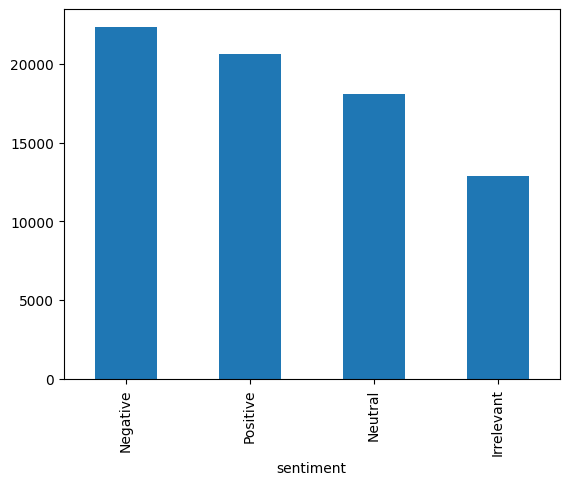

In [13]:
data['sentiment'].value_counts().plot(kind='bar')

In [14]:
#dropping id, encoding topic

In [15]:
data = data.drop('id', axis = 1)
val = val.drop('id', axis = 1)

In [16]:
data.head()

,index,topic,sentiment,tweet
0,0,Borderlands,Positive,im getting on borderlands and i will murder yo...
1,1,Borderlands,Positive,I am coming to the borders and I will kill you...
2,2,Borderlands,Positive,im getting on borderlands and i will kill you ...
3,3,Borderlands,Positive,im coming on borderlands and i will murder you...
4,4,Borderlands,Positive,im getting on borderlands 2 and i will murder ...


In [17]:
from sklearn.preprocessing import LabelEncoder

In [18]:
(data['topic'].sort_values().unique() == val['topic'].sort_values().unique()).sum()

np.int64(32)

In [19]:
topic_label = LabelEncoder()
data['topic']= pd.DataFrame(topic_label.fit_transform(data['topic']))
data['topic']

0         4
1         4
2         4
3         4
4         4
         ..
73991    21
73992    21
73993    21
73994    21
73995    21
Name: topic, Length: 73996, dtype: int64

In [20]:
val['topic']=pd.DataFrame(topic_label.transform(val['topic']))
val['topic']

0      11
1       0
2      19
3       5
4      13
       ..
995    14
996     5
997     4
998    19
999    31
Name: topic, Length: 1000, dtype: int64

In [21]:
data.head()

,index,topic,sentiment,tweet
0,0,4,Positive,im getting on borderlands and i will murder yo...
1,1,4,Positive,I am coming to the borders and I will kill you...
2,2,4,Positive,im getting on borderlands and i will kill you ...
3,3,4,Positive,im coming on borderlands and i will murder you...
4,4,4,Positive,im getting on borderlands 2 and i will murder ...


In [22]:
data = data.drop('index', axis=1)
data.head()

,topic,sentiment,tweet
0,4,Positive,im getting on borderlands and i will murder yo...
1,4,Positive,I am coming to the borders and I will kill you...
2,4,Positive,im getting on borderlands and i will kill you ...
3,4,Positive,im coming on borderlands and i will murder you...
4,4,Positive,im getting on borderlands 2 and i will murder ...


In [23]:
val.head()

,topic,sentiment,tweet
0,11,Irrelevant,I mentioned on Facebook that I was struggling ...
1,0,Neutral,BBC News - Amazon boss Jeff Bezos rejects clai...
2,19,Negative,@Microsoft Why do I pay for WORD when it funct...
3,5,Negative,"CSGO matchmaking is so full of closet hacking,..."
4,13,Neutral,Now the President is slapping Americans in the...


In [24]:
xtr = data.drop('sentiment', axis=1)

In [25]:
xts = data['sentiment']

In [26]:
valtr = val.drop('sentiment', axis=1)

In [27]:
valts = val['sentiment']

In [28]:
xts = pd.concat([pd.DataFrame(xts), pd.get_dummies(xts).astype('int32')], axis=1)

In [29]:
valts = pd.concat([pd.DataFrame(valts), pd.get_dummies(valts).astype('int32')], axis=1)

In [30]:
xts.head()

,sentiment,Irrelevant,Negative,Neutral,Positive
0,Positive,0,0,0,1
1,Positive,0,0,0,1
2,Positive,0,0,0,1
3,Positive,0,0,0,1
4,Positive,0,0,0,1


In [31]:
valts.head()

,sentiment,Irrelevant,Negative,Neutral,Positive
0,Irrelevant,1,0,0,0
1,Neutral,0,0,1,0
2,Negative,0,1,0,0
3,Negative,0,1,0,0
4,Neutral,0,0,1,0


In [32]:
xts = xts.drop('sentiment', axis=1)

In [33]:
valts = valts.drop('sentiment', axis=1)

In [34]:
# all labels are now handled

In [35]:
xtr['tweet'].isna().sum()

np.int64(0)

In [36]:
valtr.head()

,topic,tweet
0,11,I mentioned on Facebook that I was struggling ...
1,0,BBC News - Amazon boss Jeff Bezos rejects clai...
2,19,@Microsoft Why do I pay for WORD when it funct...
3,5,"CSGO matchmaking is so full of closet hacking,..."
4,13,Now the President is slapping Americans in the...


In [37]:
xtr.head()

,topic,tweet
0,4,im getting on borderlands and i will murder yo...
1,4,I am coming to the borders and I will kill you...
2,4,im getting on borderlands and i will kill you ...
3,4,im coming on borderlands and i will murder you...
4,4,im getting on borderlands 2 and i will murder ...


In [38]:
from sklearn.feature_extraction.text import TfidfVectorizer

In [39]:
vect = TfidfVectorizer()

In [40]:
vectorized = vect.fit_transform(xtr['tweet'])

In [41]:
vectorized.shape

(73996, 31062)

In [42]:
topic_col = xtr['topic'].to_numpy().reshape(-1,1)
topic_col.shape

(73996, 1)

In [43]:
from scipy import sparse

In [44]:
topic_sparse = sparse.csr_matrix(topic_col)
topic_sparse.shape

(73996, 1)

In [45]:
xtrain = sparse.hstack([vectorized, topic_sparse])

In [46]:
xtrain.shape

(73996, 31063)

In [47]:
#similarly

In [48]:
vectval = vect.transform(valtr['tweet'])
vectval.shape

(1000, 31062)

In [49]:
topic_val = valtr['topic'].to_numpy().reshape(-1,1)
topic_val.shape

(1000, 1)

In [50]:
mat_val = sparse.csr_matrix(topic_val)
mat_val.shape

(1000, 1)

In [51]:
valtrain = sparse.hstack([vectval, mat_val])

In [52]:
valtrain.shape

(1000, 31063)

In [53]:
xts.shape

(73996, 4)

In [54]:
valts.shape

(1000, 4)

In [55]:
#looks good till here, tfidf is flat, thus only dense layers required, later model will be with gru

In [56]:
#beginning model definition

In [57]:
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Bidirectional, GRU, Dense, Input, Dropout, Embedding
from tensorflow.keras.optimizers import Adam

C:\Users\Abhishek\tf-env\Lib\site-packages\keras\src\export\tf2onnx_lib.py:8: FutureWarning: In the future `np.object` will be defined as the corresponding NumPy scalar.
  if not hasattr(np, "object"):


In [58]:
sentiment_dense  = Sequential()

sentiment_dense.add(Input(shape=(31063,)))
sentiment_dense.add(Dense(128, activation = 'relu'))
sentiment_dense.add(Dropout(0.1))
sentiment_dense.add(Dense(64, activation = 'relu'))
sentiment_dense.add(Dropout(0.1))
sentiment_dense.add(Dense(32, activation = 'relu'))
sentiment_dense.add(Dense(4, activation = 'softmax'))

sentiment_dense.compile(loss='categorical_crossentropy', optimizer = Adam(learning_rate=0.001), metrics = ['accuracy'])

In [59]:
sentiment_dense.summary()

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━┓
┃ Layer (type)                         ┃ Output Shape                ┃         Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━┩
│ dense (Dense)                        │ (None, 128)                 │       3,976,192 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dropout (Dropout)                    │ (None, 128)                 │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense_1 (Dense)                      │ (None, 64)                  │           8,256 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dropout_1 (Dropout)                  │ (None, 64)                  │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense_2 (Dense)                      │ (None, 32)                  │           2,080 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense_3 (Dense)                      │ (None, 4)                   │             132 │
└──────────────────────────────────────┴─────────────────────────────┴─────────────────┘

 Total params: 3,986,660 (15.21 MB)

 Trainable params: 3,986,660 (15.21 MB)

 Non-trainable params: 0 (0.00 B)

In [60]:
from tensorflow.keras.callbacks import EarlyStopping

In [61]:
early_stop = EarlyStopping(mode='min', monitor='val_loss', patience = 15, restore_best_weights=True)

In [62]:
sentiment_dense.fit(xtrain,xts, validation_data=(valtrain, valts), epochs=2000, callbacks = [early_stop])

Epoch 1/2000
2313/2313 ━━━━━━━━━━━━━━━━━━━━ 34s 14ms/step - accuracy: 0.7161 - loss: 0.7184 - val_accuracy: 0.9530 - val_loss: 0.1528
Epoch 2/2000
2313/2313 ━━━━━━━━━━━━━━━━━━━━ 33s 14ms/step - accuracy: 0.9138 - loss: 0.2393 - val_accuracy: 0.9740 - val_loss: 0.1034
Epoch 3/2000
2313/2313 ━━━━━━━━━━━━━━━━━━━━ 32s 14ms/step - accuracy: 0.9438 - loss: 0.1513 - val_accuracy: 0.9740 - val_loss: 0.0937
Epoch 4/2000
2313/2313 ━━━━━━━━━━━━━━━━━━━━ 34s 15ms/step - accuracy: 0.9545 - loss: 0.1174 - val_accuracy: 0.9710 - val_loss: 0.1250
Epoch 5/2000
2313/2313 ━━━━━━━━━━━━━━━━━━━━ 33s 14ms/step - accuracy: 0.9604 - loss: 0.0997 - val_accuracy: 0.9780 - val_loss: 0.1049
Epoch 6/2000
2313/2313 ━━━━━━━━━━━━━━━━━━━━ 32s 14ms/step - accuracy: 0.9630 - loss: 0.0910 - val_accuracy: 0.9770 - val_loss: 0.1255
Epoch 7/2000
2313/2313 ━━━━━━━━━━━━━━━━━━━━ 32s 14ms/step - accuracy: 0.9650 - loss: 0.0837 - val_accuracy: 0.9750 - val_loss: 0.1287
Epoch 8/2000
2313/2313 ━━━━━━━━━━━━━━━━━━━━ 32s 14ms/step - ac

In [63]:
metrics = pd.DataFrame(sentiment_dense.history.history)

In [64]:
metrics.head()

,accuracy,loss,val_accuracy,val_loss
0,0.716093,0.718379,0.953,0.152848
1,0.913766,0.239260,0.974,0.103421
2,0.943808,0.151253,0.974,0.093725
3,0.954525,0.117417,0.971,0.124975
4,0.960403,0.099747,0.978,0.104922


<Axes: >

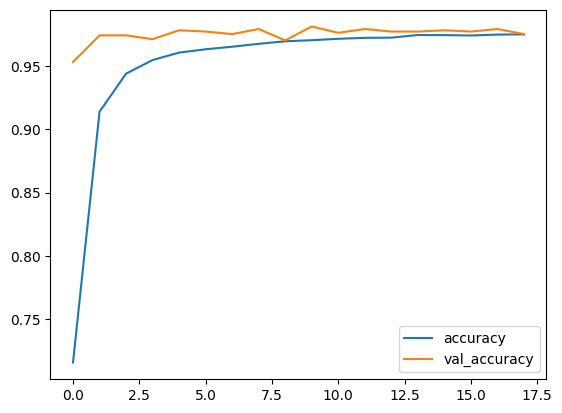

In [65]:
metrics[['accuracy', 'val_accuracy']].plot()

<Axes: >

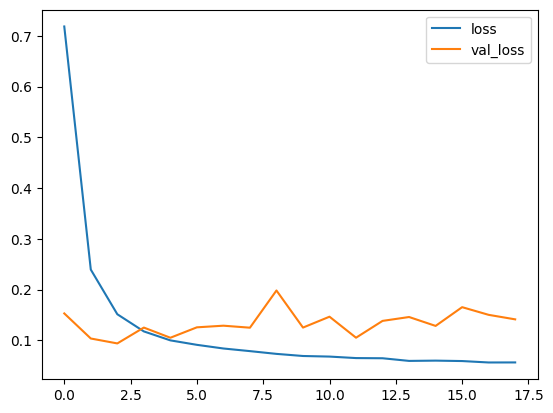

In [66]:
metrics[['loss', 'val_loss']].plot()

In [67]:
from sklearn.metrics import classification_report, confusion_matrix, accuracy_score

In [68]:
sentiment_dense.evaluate(valtrain, valts)

32/32 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - accuracy: 0.9740 - loss: 0.0937


[0.09372519701719284, 0.9739999771118164]

In [69]:
pred = sentiment_dense.predict(valtrain)

32/32 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step


In [70]:
pred = np.argmax(pred, axis=-1)

In [71]:
y_true = np.argmax(valts, axis = -1)

In [72]:
accuracy_score(y_true, pred)

0.974

<Axes: >

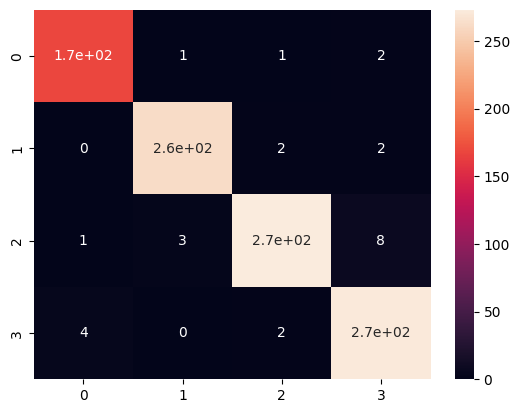

In [73]:
sns.heatmap(confusion_matrix(y_true, pred), annot = True)

In [74]:
print(classification_report(y_true, pred))

              precision    recall  f1-score   support

           0       0.97      0.98      0.97       172
           1       0.98      0.98      0.98       266
           2       0.98      0.96      0.97       285
           3       0.96      0.98      0.97       277

    accuracy                           0.97      1000
   macro avg       0.97      0.97      0.97      1000
weighted avg       0.97      0.97      0.97      1000



In [75]:
# it is near perfect, now we check with gru layers, processing data first

In [76]:
xtr

,topic,tweet
0,4,im getting on borderlands and i will murder yo...
1,4,I am coming to the borders and I will kill you...
2,4,im getting on borderlands and i will kill you ...
3,4,im coming on borderlands and i will murder you...
4,4,im getting on borderlands 2 and i will murder ...
...,...,...
73991,21,Just realized that the Windows partition of my...
73992,21,Just realized that my Mac window partition is ...
73993,21,Just realized the windows partition of my Mac ...
73994,21,Just realized between the windows partition of...


In [77]:
xts

,Irrelevant,Negative,Neutral,Positive
0,0,0,0,1
1,0,0,0,1
2,0,0,0,1
3,0,0,0,1
4,0,0,0,1
...,...,...,...,...
73991,0,0,0,1
73992,0,0,0,1
73993,0,0,0,1
73994,0,0,0,1


In [78]:
valtr

,topic,tweet
0,11,I mentioned on Facebook that I was struggling ...
1,0,BBC News - Amazon boss Jeff Bezos rejects clai...
2,19,@Microsoft Why do I pay for WORD when it funct...
3,5,"CSGO matchmaking is so full of closet hacking,..."
4,13,Now the President is slapping Americans in the...
...,...,...
995,14,⭐️ Toronto is the arts and culture capital of ...
996,5,tHIS IS ACTUALLY A GOOD MOVE TOT BRING MORE VI...
997,4,Today sucked so it’s time to drink wine n play...
998,19,Bought a fraction of Microsoft today. Small wins.


In [79]:
valts

,Irrelevant,Negative,Neutral,Positive
0,1,0,0,0
1,0,0,1,0
2,0,1,0,0
3,0,1,0,0
4,0,0,1,0
...,...,...,...,...
995,1,0,0,0
996,1,0,0,0
997,0,0,0,1
998,0,0,0,1


In [80]:
#originals

In [81]:
from tensorflow.keras.preprocessing.text import Tokenizer
from tensorflow.keras.utils import pad_sequences

In [82]:
max_words = 20000
max_len = 40
# hyperparams

In [83]:
token = Tokenizer(num_words=max_words)

In [84]:
token.fit_on_texts(xtr['tweet'])

In [85]:
vocab_size = min(max_words, len(token.word_index)+1)
vocab_size

20000

In [86]:
T = xtr['topic'].nunique()
T

32

In [90]:
def encode_with_topic(text, topic_id):
    seq = token.texts_to_sequences([text])[0]
    seq.append(vocab_size + int(topic_id))
    return seq

In [91]:
train_seqs = [
    encode_with_topic(t, topic_id)
    for t, topic_id in zip(xtr["tweet"], xtr["topic"])
]


In [96]:
x_train = pad_sequences(train_seqs, maxlen=max_len,
                        padding="post", truncating="post")

In [97]:
val_seqs = [
    encode_with_topic(t, topic_id)
    for t, topic_id in zip(valtr["tweet"], valtr["topic"])
]

In [98]:
x_val = pad_sequences(val_seqs, maxlen=max_len,
                      padding="post", truncating="post")

In [99]:
x_train.shape

(73996, 40)

In [100]:
x_val.shape

(1000, 40)

In [103]:
new_vocab=vocab_size+T

In [107]:
# defining the model

In [108]:
sentiment_GRU = Sequential()

sentiment_GRU.add(Input([40]))
sentiment_GRU.add(Embedding(new_vocab, 128))
sentiment_GRU.add(Bidirectional(GRU(128, recurrent_dropout=0.2, recurrent_initializer='glorot_uniform', return_sequences=False)))
sentiment_GRU.add(Dense(64, activation = 'relu'))
sentiment_GRU.add(Dropout(0.1))
sentiment_GRU.add(Dense(32, activation = 'relu'))
sentiment_GRU.add(Dense(4, activation = 'softmax'))

sentiment_GRU.compile(loss='categorical_crossentropy', optimizer = Adam(learning_rate=0.001), metrics = ['accuracy'])

In [109]:
sentiment_GRU.summary()

Model: "sequential_3"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━┓
┃ Layer (type)                         ┃ Output Shape                ┃         Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━┩
│ embedding_1 (Embedding)              │ (None, 40, 128)             │       2,564,096 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ bidirectional_1 (Bidirectional)      │ (None, 256)                 │         198,144 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense_7 (Dense)                      │ (None, 64)                  │          16,448 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dropout_3 (Dropout)                  │ (None, 64)                  │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense_8 (Dense)                      │ (None, 32)                  │           2,080 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense_9 (Dense)                      │ (None, 4)                   │             132 │
└──────────────────────────────────────┴─────────────────────────────┴─────────────────┘

 Total params: 2,780,900 (10.61 MB)

 Trainable params: 2,780,900 (10.61 MB)

 Non-trainable params: 0 (0.00 B)

In [110]:
sentiment_GRU.fit(x_train, xts, validation_data=(x_val,valts), epochs = 2000, callbacks=[early_stop])

Epoch 1/2000
2313/2313 ━━━━━━━━━━━━━━━━━━━━ 77s 32ms/step - accuracy: 0.6956 - loss: 0.7604 - val_accuracy: 0.9140 - val_loss: 0.2503
Epoch 2/2000
2313/2313 ━━━━━━━━━━━━━━━━━━━━ 74s 32ms/step - accuracy: 0.8901 - loss: 0.3027 - val_accuracy: 0.9520 - val_loss: 0.1427
Epoch 3/2000
2313/2313 ━━━━━━━━━━━━━━━━━━━━ 73s 32ms/step - accuracy: 0.9276 - loss: 0.1951 - val_accuracy: 0.9540 - val_loss: 0.1486
Epoch 4/2000
2313/2313 ━━━━━━━━━━━━━━━━━━━━ 74s 32ms/step - accuracy: 0.9422 - loss: 0.1513 - val_accuracy: 0.9740 - val_loss: 0.1202
Epoch 5/2000
2313/2313 ━━━━━━━━━━━━━━━━━━━━ 74s 32ms/step - accuracy: 0.9516 - loss: 0.1247 - val_accuracy: 0.9470 - val_loss: 0.1866
Epoch 6/2000
2313/2313 ━━━━━━━━━━━━━━━━━━━━ 75s 32ms/step - accuracy: 0.9578 - loss: 0.1073 - val_accuracy: 0.9600 - val_loss: 0.1395
Epoch 7/2000
2313/2313 ━━━━━━━━━━━━━━━━━━━━ 75s 33ms/step - accuracy: 0.9631 - loss: 0.0925 - val_accuracy: 0.9690 - val_loss: 0.1068
Epoch 8/2000
2313/2313 ━━━━━━━━━━━━━━━━━━━━ 75s 33ms/step - ac

In [111]:
metrics = pd.DataFrame(sentiment_GRU.history.history)

In [112]:
metrics

,accuracy,loss,val_accuracy,val_loss
0,0.695619,0.760430,0.914,0.250289
1,0.890116,0.302720,0.952,0.142736
2,0.927618,0.195102,0.954,0.148613
3,0.942200,0.151328,0.974,0.120152
4,0.951605,0.124691,0.947,0.186556
5,0.957849,0.107289,0.960,0.139463
6,0.963120,0.092537,0.969,0.106778
7,0.965917,0.083795,0.960,0.150430
8,0.968201,0.077537,0.968,0.165352
9,0.970363,0.071078,0.971,0.161071


<Axes: >

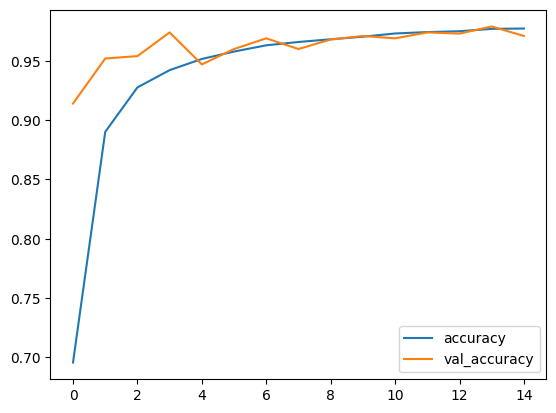

In [113]:
metrics[['accuracy', 'val_accuracy']].plot()

<Axes: >

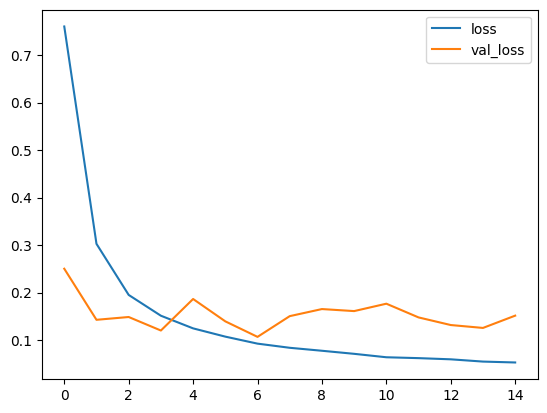

In [114]:
metrics[['loss', 'val_loss']].plot()

In [121]:
sentiment_GRU.evaluate(x_val, valts)

32/32 ━━━━━━━━━━━━━━━━━━━━ 0s 12ms/step - accuracy: 0.9140 - loss: 0.2503


[0.25028932094573975, 0.9139999747276306]

In [122]:
pred = sentiment_GRU.predict(x_val)

32/32 ━━━━━━━━━━━━━━━━━━━━ 0s 10ms/step


In [123]:
pred = np.argmax(pred, axis = -1)
pred

array([0, 2, 1, 1, 2, 1, 3, 3, 3, 1, 3, 3, 1, 2, 1, 3, 3, 1, 3, 1, 3, 2,
       0, 1, 2, 2, 1, 1, 0, 1, 3, 3, 1, 3, 1, 2, 2, 0, 3, 2, 3, 2, 2, 2,
       3, 2, 3, 1, 3, 2, 3, 1, 1, 3, 3, 3, 3, 3, 1, 0, 1, 3, 3, 0, 1, 2,
       1, 0, 2, 1, 2, 1, 3, 3, 3, 0, 3, 0, 2, 2, 2, 3, 3, 2, 3, 2, 1, 0,
       3, 2, 2, 2, 3, 0, 0, 1, 1, 2, 3, 3, 2, 1, 3, 3, 2, 3, 2, 3, 1, 2,
       2, 2, 1, 2, 1, 2, 2, 3, 3, 2, 1, 1, 3, 1, 2, 1, 3, 2, 3, 2, 0, 3,
       3, 3, 3, 0, 2, 2, 0, 0, 0, 2, 2, 0, 0, 0, 3, 2, 3, 0, 3, 1, 3, 2,
       2, 0, 2, 1, 2, 3, 3, 2, 1, 0, 1, 0, 2, 3, 1, 1, 3, 3, 3, 2, 2, 3,
       0, 2, 2, 2, 3, 2, 1, 1, 2, 3, 3, 0, 0, 2, 3, 3, 2, 0, 3, 1, 1, 1,
       1, 3, 2, 2, 3, 3, 3, 3, 3, 3, 3, 0, 2, 0, 1, 1, 0, 0, 1, 3, 3, 1,
       3, 1, 3, 3, 1, 0, 0, 3, 3, 1, 3, 0, 2, 0, 0, 1, 2, 2, 2, 3, 0, 0,
       3, 3, 0, 0, 2, 3, 1, 1, 3, 3, 3, 3, 2, 2, 3, 1, 2, 3, 2, 1, 2, 2,
       1, 3, 3, 0, 1, 2, 0, 3, 2, 3, 1, 2, 1, 3, 3, 1, 1, 1, 3, 1, 2, 3,
       2, 2, 1, 3, 1, 3, 1, 0, 2, 2, 3, 1, 2, 1, 0,

In [125]:
true_val = np.argmax(valts, axis=-1)

In [126]:
accuracy_score(true_val, pred)

0.914

<Axes: >

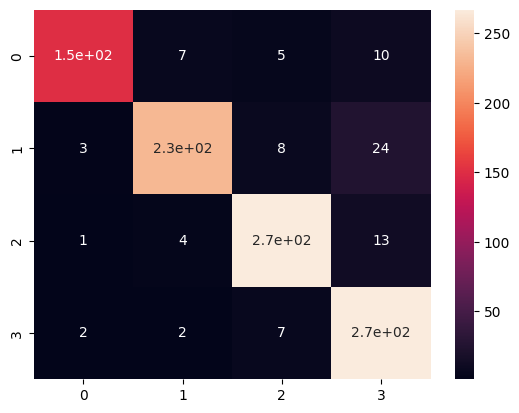

In [129]:
sns.heatmap(confusion_matrix(true_val, pred), annot = True)

In [130]:
print(classification_report(true_val,pred))

              precision    recall  f1-score   support

           0       0.96      0.87      0.91       172
           1       0.95      0.87      0.91       266
           2       0.93      0.94      0.93       285
           3       0.85      0.96      0.90       277

    accuracy                           0.91      1000
   macro avg       0.92      0.91      0.91      1000
weighted avg       0.92      0.91      0.91      1000

